# SkillCompass — EDA

IT-аналитики (BA / SA / PA / DA): зарплаты, роли, источники HH + SuperJob.

Данные: `data/processed/vacancies.parquet` (создаётся `python scripts/fetch_all.py`)

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parents[1]
elif (ROOT / "ml").exists():
    pass
else:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "ml"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from load_data import load_vacancies, prepare_salary_target

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = load_vacancies()
df = prepare_salary_target(df)
print(f"Вакансий: {len(df)}")
print("Источники:", df["source"].value_counts().to_dict())
print("\nРоли:")
print(df["role_label"].value_counts() if "role_label" in df else df["analyst_role"].value_counts())
df.head()

Вакансий: 699
Источники: {'hh': 615, 'superjob': 84}

Роли:
role_label
Аналитик данных         191
Продуктовый аналитик    187
Бизнес-аналитик         162
Системный аналитик      159
Name: count, dtype: int64


,source,external_id,title,analyst_role,employer,area,experience,employment,schedule,salary_from,salary_to,salary_currency,salary_gross,description,url,published_at,role_label,collected_at,salary_mid
0,hh,134540908,Системный аналитик,business_analyst,STARTRIBE LTD. Бэк-офис,Тбилиси,Опыт 3-6 лет,NaN,None,NaN,NaN,NaN,None,NaN,https://hh.ru/vacancy/134540908,NaN,Бизнес-аналитик,2026-06-24T18:03:50.203599+00:00,NaN
1,hh,133870314,Лид BI-аналитиков,business_analyst,Т-Банк. ИТ. Разработка,"Санкт-Петербург, р-н Калининский",Опыт более 6 лет,NaN,None,NaN,NaN,NaN,None,NaN,https://hh.ru/vacancy/133870314,NaN,Бизнес-аналитик,2026-06-24T18:03:50.203628+00:00,NaN
2,hh,134471240,Business Analyst (Junior/Middle),business_analyst,АИКБ ИПАК ЙУЛИ БАНК,"Ташкент, Алмазарский район, Малая кольцевая до...",Опыт 1-3 года,NaN,None,NaN,NaN,NaN,None,NaN,https://hh.ru/vacancy/134471240,NaN,Бизнес-аналитик,2026-06-24T18:03:50.203636+00:00,NaN
3,hh,134105465,Менеджер по продажам крупному бизнесу,business_analyst,ОООHeadHunter::Телефонные продажи,Ташкент,Опыт 3-6 лет,NaN,None,NaN,NaN,NaN,None,NaN,https://hh.ru/vacancy/134105465,NaN,Бизнес-аналитик,2026-06-24T18:03:50.203641+00:00,NaN
4,hh,134537692,Business Development Manager/Менеджер по разви...,business_analyst,ОООЛСофт Лаборатория,"Ташкент, проспект Мустакиллик, 88A",Опыт 3-6 лет,NaN,None,NaN,NaN,NaN,None,NaN,https://hh.ru/vacancy/134537692,NaN,Бизнес-аналитик,2026-06-24T18:03:50.203646+00:00,NaN


## Гипотеза 1: зарплаты системных аналитиков выше бизнес-аналитиков

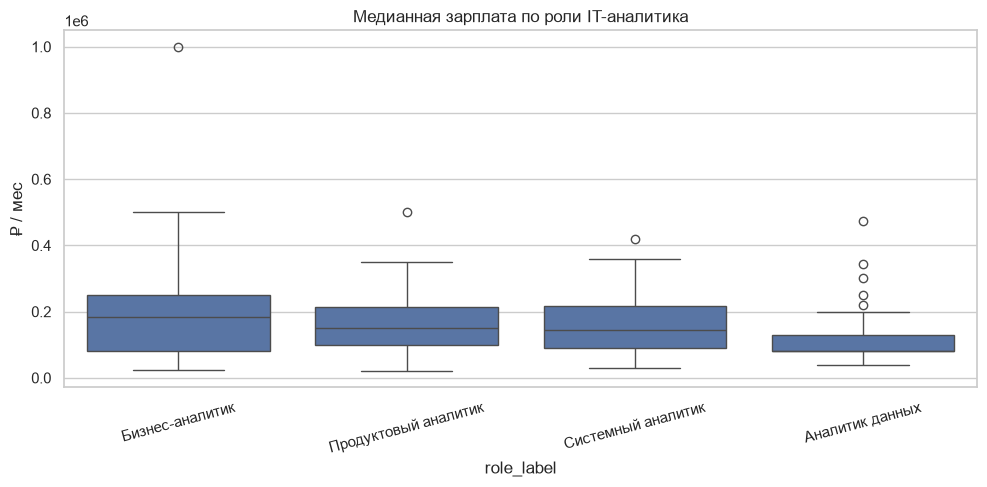

In [3]:
paid = df.dropna(subset=["salary_mid"])
order = paid.groupby("role_label")["salary_mid"].median().sort_values(ascending=False).index
sns.boxplot(data=paid, x="role_label", y="salary_mid", order=order)
plt.xticks(rotation=15)
plt.title("Медианная зарплата по роли IT-аналитика")
plt.ylabel("₽ / мес")
plt.tight_layout()
plt.show()

## Гипотеза 2: доля вакансий с указанной зарплатой различается по источникам

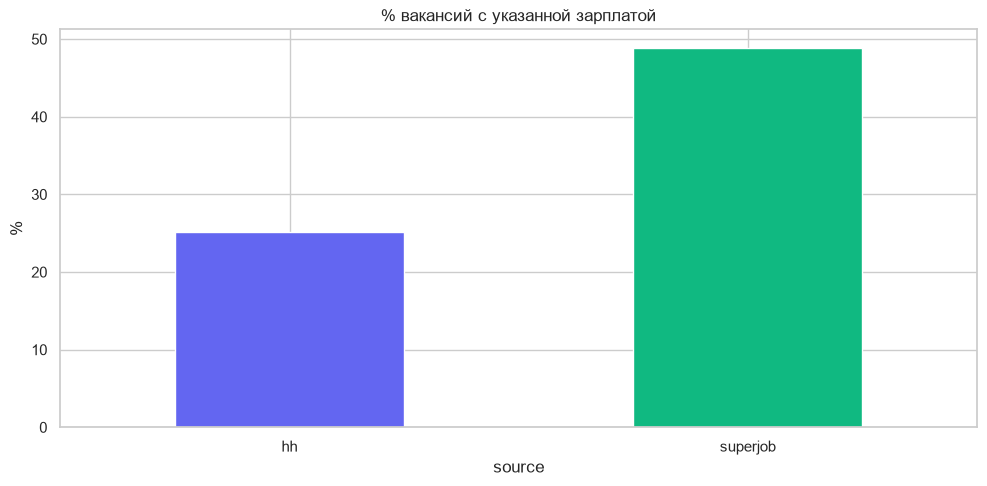

source
hh          25.2
superjob    48.8
Name: has_salary, dtype: float64

In [4]:
df["has_salary"] = df["salary_mid"].notna()
rate = df.groupby("source")["has_salary"].mean().mul(100).round(1)
rate.plot(kind="bar", color=["#6366f1", "#10b981"])
plt.title("% вакансий с указанной зарплатой")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
rate

## Гипотеза 3: опыт влияет на зарплату

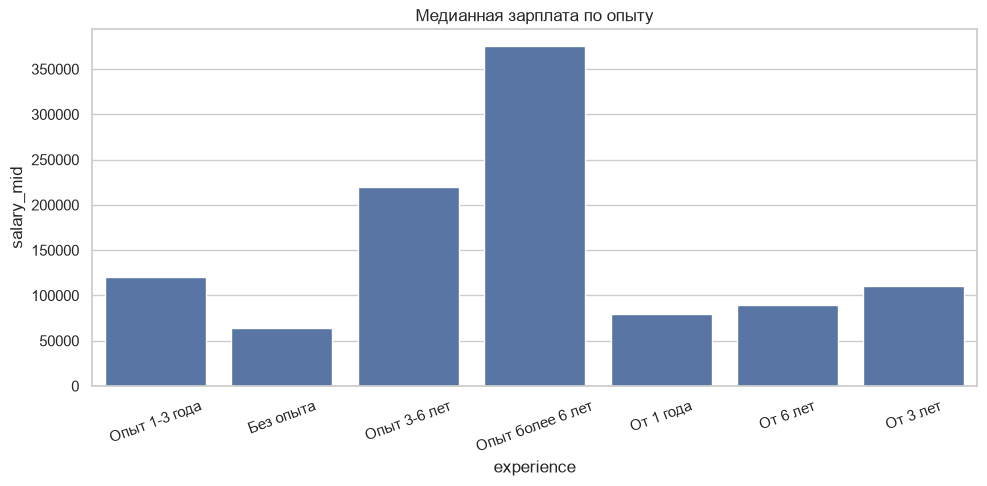

In [5]:
exp = paid.dropna(subset=["experience"])
sns.barplot(data=exp, x="experience", y="salary_mid", estimator="median", errorbar=None)
plt.xticks(rotation=20)
plt.title("Медианная зарплата по опыту")
plt.tight_layout()
plt.show()

## Выводы

1. Рынок IT-аналитиков неоднороден: разные роли дают разные медианы.
2. HH и SuperJob по-разному указывают зарплату в объявлениях.
3. Для ML используем `analyst_role`, `experience`, `area`, `source` как признаки.